In [9]:
import importlib
import sys
sys.path.append('../')  # Add parent directory to path for imports
from ingestion.data_paths import DataStorageManager
from ingestion.ephys_sync import DataSyncManager
from ingestion.kilosort_data_import import KilosortData
from video.behavioral_events import BehavioralEventsData


animal_id = "rat631"
session_date = "20251216"
data_storage = DataStorageManager(animal_id, session_date, auto_load=True)
behavior_data = BehavioralEventsData(data_storage)
ks_data = KilosortData(data_storage)
sync = DataSyncManager(data_storage, dio_channel=1)
behavior_data.synchronize_with_ephys(sync, create_new_columns=True)


Loading data paths for rat631/20251216
  ✓ Kilosort path: \\nearline\karpova\TervoLab\data\Electrophysiology\Raw\rat_city\cohort7\20251216_094334.rec\rat631\20251216_094334_merged.kilosort\kilosort4
  ✓ DIO channel 1: \\nearline\karpova\TervoLab\data\Electrophysiology\Raw\rat_city\cohort7\20251216_094334.rec\rat631\20251216_094334_merged.DIO\20251216_094334_merged.dio_Controller_Din1.dat
  ✓ DIO channel 2: \\nearline\karpova\TervoLab\data\Electrophysiology\Raw\rat_city\cohort7\20251216_094334.rec\rat631\20251216_094334_merged.DIO\20251216_094334_merged.dio_Controller_Din2.dat
  ✓ DIO channel 3: \\nearline\karpova\TervoLab\data\Electrophysiology\Raw\rat_city\cohort7\20251216_094334.rec\rat631\20251216_094334_merged.DIO\20251216_094334_merged.dio_Controller_Din3.dat
  ✓ DIO channel 4: \\nearline\karpova\TervoLab\data\Electrophysiology\Raw\rat_city\cohort7\20251216_094334.rec\rat631\20251216_094334_merged.DIO\20251216_094334_merged.dio_Controller_Din4.dat
  ✓ Found 48 video files
Found ma

c:\Users\proskurinm\GitHub\habitat_pipeline\ephys\..\ingestion\trodes_to_python.py:63: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return np.dtype(typearr)


Found start sequence match: B[74791] -> E[0]
Extension stopped: interval tolerance exceeded. diff: 1.7711 > 0.02
Final extended sequence length: 158
Interpolation slope 1.0000072105973188
Successfully created interval mapping
=== Sync Mapping Summary ===
Method: Linear regression
R²: 1.000000
Matches: 158
Slope: 1.00000721
Synchronizing 641 behavioral events with ephys timestamps...
Converting start timestamps...
Converting end timestamps...
Synchronization complete:
  ✓ Start timestamps: 641/641 converted
  ✓ End timestamps: 641/641 converted
  ✓ New columns created: ts_start_ephys, ts_end_ephys


True


1. Loading behavioral events data...
Loading 1 behavioral event file(s)...
  ✓ Loaded 20251216_behavior_event_df.csv: 641 events
Successfully loaded 1 file(s) with 641 total events
Synchronizing 641 behavioral events with ephys timestamps...
Converting start timestamps...
Converting end timestamps...
Synchronization complete:
  ✓ Start timestamps: 641/641 converted
  ✓ End timestamps: 641/641 converted
  ✓ New columns created: ts_start_ephys, ts_end_ephys
✓ Loaded 641 behavioral events
✓ Available behavior types: {'EC': 376, 'F': 71, 'PS': 71, 'C': 46, 'SN': 31, 'D': 16, 'P': 15, 'PO': 5, 'R': 5, 'HD': 4, 'UD': 1}
✓ Found initiator/victim columns for opponent identification
✓ Initiator IDs: {'rat631': 168, 'rat630': 121, 'rat613': 113, 'rat617': 68, 'rat634': 67, 'rat615': 27, 'rat635': 26, 'rat629': 25, 'rat616': 13, 'rat620': 12}
✓ Victim IDs: {'rat635': 115, 'rat634': 109, 'rat617': 90, 'rat629': 87, 'rat631': 65, 'rat613': 49, 'rat616': 48, 'rat620': 35, 'rat630': 23, 'rat615': 19

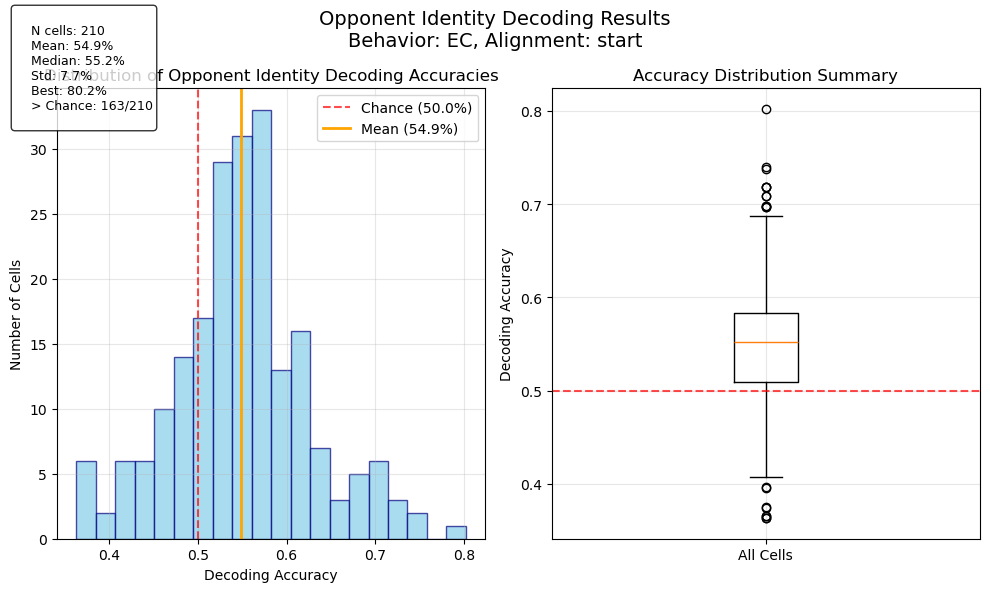

✓ Generated accuracy distribution plot


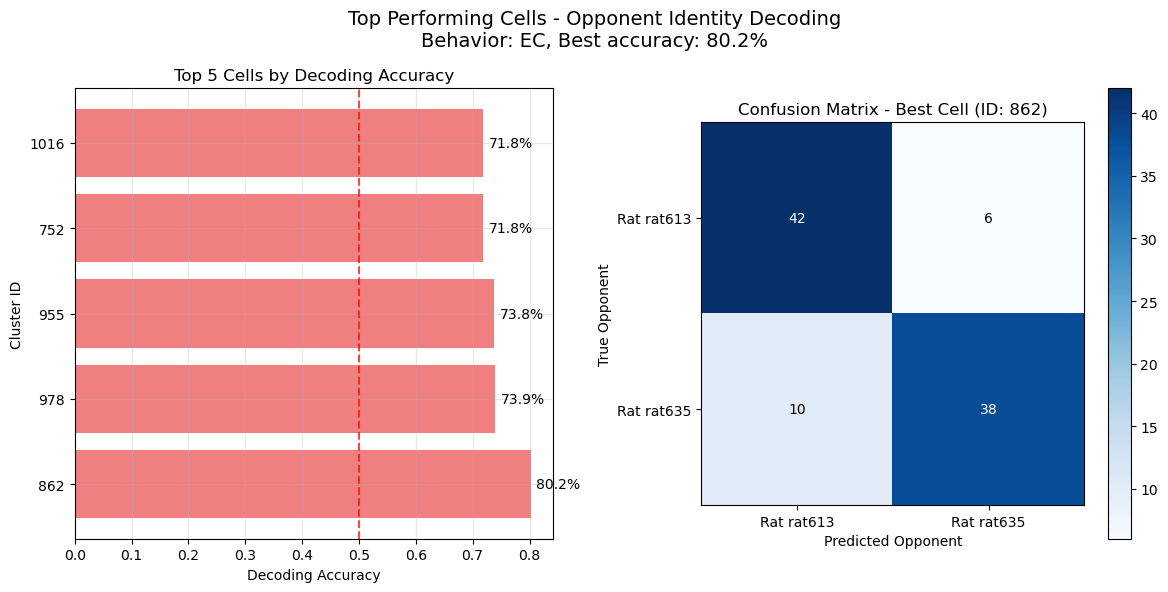

✓ Generated best cells plot


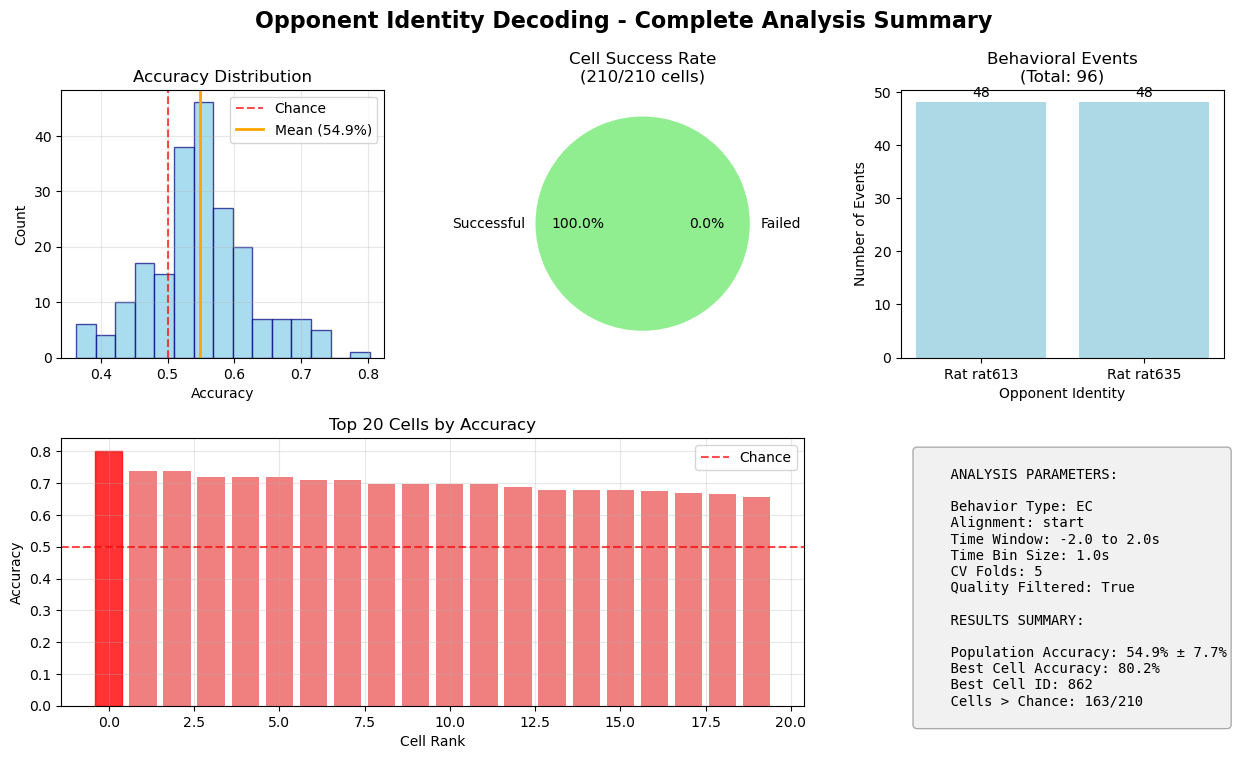

✓ Generated comprehensive summary plot

5. Usage examples for the decoding module:
Command line usage:
  python ephys/decode_opponent_identity.py --animal_id 631 --session_id 20251216 --behavior_type F --save_plots

Python import usage:
  from ephys.decode_opponent_identity import decode_opponent_identity_population
  results = decode_opponent_identity_population(ks_data, behavior_data, animal_of_interest='631', behavior_type='F')

OPPONENT IDENTITY DECODING MODULE TEST COMPLETE


In [12]:
# Import the new decoding module
import ephys.decode_opponent_identity as doi
import numpy as np
import matplotlib.pyplot as plt
animal_id = "rat631"
print("\n1. Loading behavioral events data...")
try:
    # Create data manager and load behavioral events
    behavior_data = BehavioralEventsData(data_storage)
    behavior_data.synchronize_with_ephys(sync, create_new_columns=True)

    print(f"✓ Loaded {len(behavior_data.events_data)} behavioral events")
    
    # Check available behavior types
    if 'type' in behavior_data.events_data.columns:
        behavior_types = behavior_data.events_data['type'].value_counts()
        print(f"✓ Available behavior types: {dict(behavior_types)}")
    
    # Check if we have opponent information
    if 'initiator' in behavior_data.events_data.columns and 'victim' in behavior_data.events_data.columns:
        print("✓ Found initiator/victim columns for opponent identification")
        initiators = behavior_data.events_data['initiator'].value_counts()
        victims = behavior_data.events_data['victim'].value_counts()
        print(f"✓ Initiator IDs: {dict(initiators)}")
        print(f"✓ Victim IDs: {dict(victims)}")
    else:
        print("⚠ No opponent columns found - will check for other opponent columns")
        
except Exception as e:
    print(f"✗ Error loading behavioral data: {e}")
    behavior_data = None

if behavior_data is not None:
    print(f"\n2. Testing opponent identity extraction...")
    try:
        # Test extracting opponent labels for fights with animal of interest
        event_starts, event_ends, opponent_labels = doi.extract_behavioral_opponent_labels(
            behavior_data, 
            animal_of_interest=animal_id,
            behavior_type='EC',
            min_events_per_class=30
        )
        print(f"✓ Found {len(event_starts)} encounter events with opponent labels")
        print(f"✓ Unique opponents: {np.unique(opponent_labels)}")
        
        if len(event_starts) > 0:
            print(f"✓ Event time range: {event_starts[0]:.1f}s to {event_starts[-1]:.1f}s")
    except Exception as e:
        print(f"✗ Error extracting opponent labels: {e}")
        event_starts = None

if behavior_data is not None and len(behavior_data.events_data) > 0:
    print(f"\n3. Running opponent identity decoding (small test)...")
    try:
        # Run decoding with a small subset for testing
        test_results = doi.decode_opponent_identity_population(
            ks_data=ks_data,
            behavior_data=behavior_data,
            animal_of_interest=animal_id,
            behavior_type='EC',  # Encounter events
            use_quality_cells=True,
            alignment='start',
            time_window=(-2.0, 2.0),  # Smaller window for faster testing
            time_bin_size=1.0, # Larger bins for faster testing
            cv_folds=5,  # Fewer folds for faster testing
            min_events_per_class=30  # Lower threshold for testing
        )
        
        if test_results['status'] == 'success':
            print(f"✓ SUCCESS! Decoded {test_results['n_successful_cells']}/{test_results['n_total_cells']} cells")
            print(f"✓ Population accuracy: {test_results['population_accuracy_mean']:.1%} ± {test_results['population_accuracy_std']:.1%}")
            print(f"✓ Best cell: {test_results['best_cell_id']} ({test_results['best_cell_accuracy']:.1%} accuracy)")
            
            # Show some individual results
            print(f"\n✓ Top 3 cells:")
            cell_accs = [(cid, test_results['cell_results'][cid]['accuracy']) 
                        for cid in test_results['successful_cells']
                        if not np.isnan(test_results['cell_results'][cid]['accuracy'])]
            cell_accs_sorted = sorted(cell_accs, key=lambda x: x[1], reverse=True)
            
            for i, (cell_id, acc) in enumerate(cell_accs_sorted[:3]):
                print(f"   Cell {cell_id}: {acc:.1%} accuracy")
        else:
            print(f"✗ Decoding failed: {test_results.get('error', 'Unknown error')}")
            test_results = None
            
    except Exception as e:
        print(f"✗ Error during decoding: {e}")
        test_results = None
        
    print(f"\n4. Testing visualization functions...")
    if test_results is not None and test_results['status'] == 'success':
        try:
            # Test accuracy distribution plot
            fig1 = doi.plot_decoding_accuracy_distribution(test_results, figsize=(10, 6))
            if fig1 is not None:
                plt.show()
                print("✓ Generated accuracy distribution plot")
            
            # Test best cells plot
            fig2 = doi.plot_best_cells_decoding(test_results, n_top_cells=5, figsize=(12, 6))
            if fig2 is not None:
                plt.show() 
                print("✓ Generated best cells plot")
                
            # Test summary plot
            fig3 = doi.plot_decoding_summary(test_results, figsize=(15, 8))
            if fig3 is not None:
                plt.show()
                print("✓ Generated comprehensive summary plot")
                
        except Exception as e:
            print(f"✗ Error creating plots: {e}")
    
print(f"\n5. Usage examples for the decoding module:")
print("Command line usage:")
print("  python ephys/decode_opponent_identity.py --animal_id 631 --session_id 20251216 --behavior_type F --save_plots")
print("\nPython import usage:")
print("  from ephys.decode_opponent_identity import decode_opponent_identity_population")
print("  results = decode_opponent_identity_population(ks_data, behavior_data, animal_of_interest='631', behavior_type='F')")

print(f"\n" + "="*70)
print("OPPONENT IDENTITY DECODING MODULE TEST COMPLETE")
print("="*70)

🔥 Testing new peri-event firing rate plot...
✅ Plotting firing rates for top cells around EC events


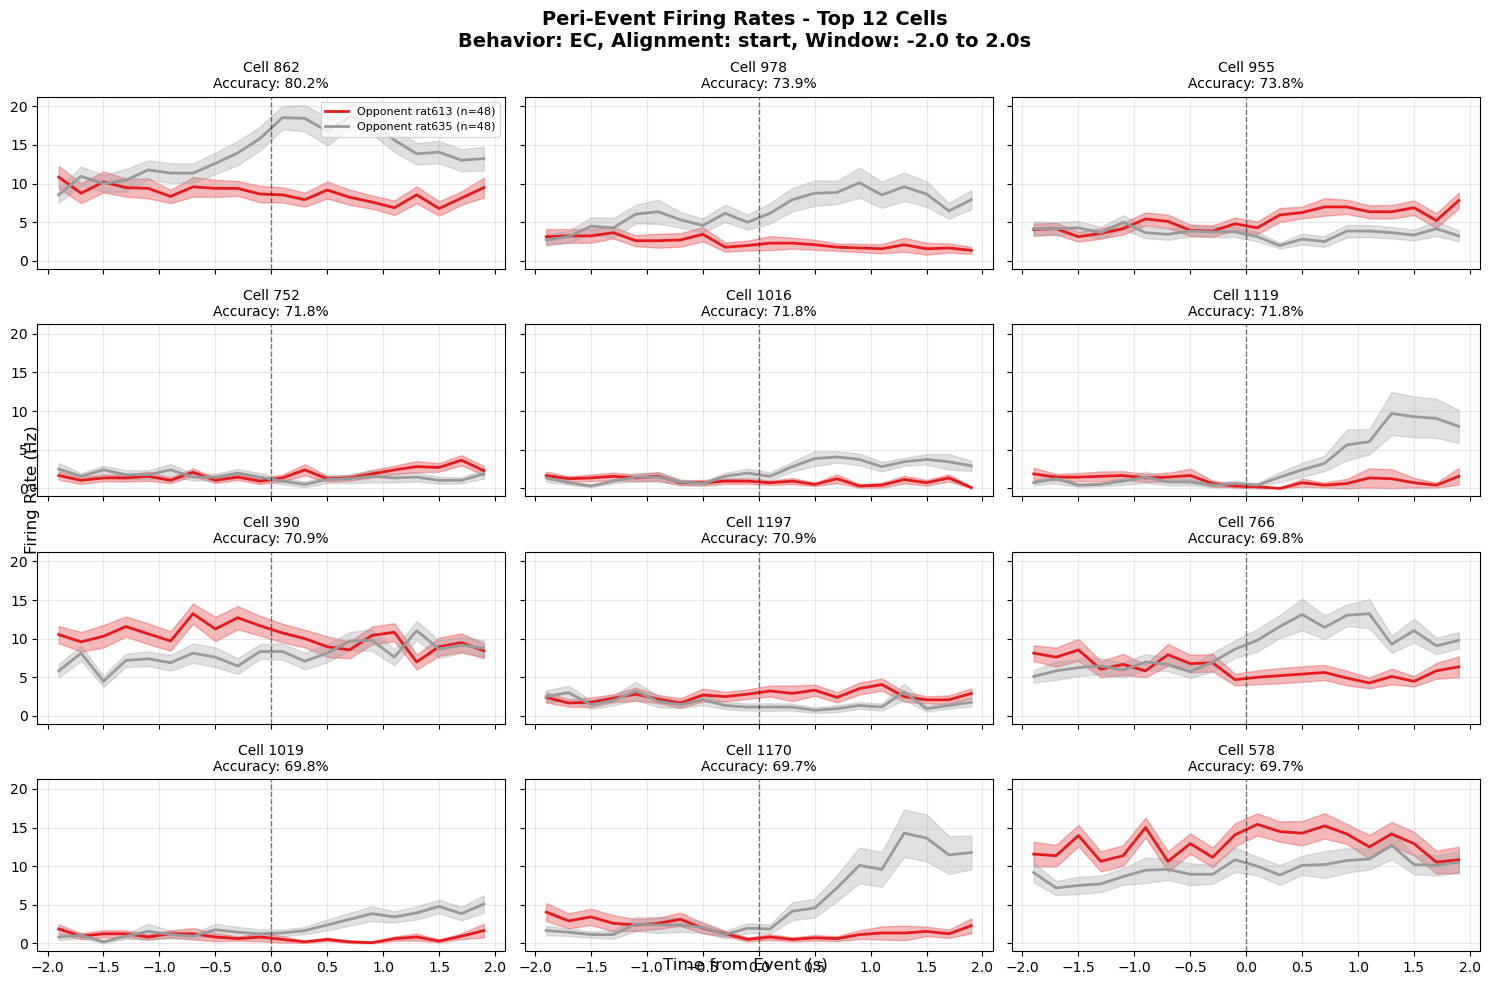

✅ Generated peri-event time histogram (PETH) plot for top cells
📊 Shows average firing rates ± SEM for each opponent class

🎯 The new plot shows:
   • Peri-event time histograms (PETHs) for the best decoding cells
   • Average firing rate over time for each opponent class
   • Standard error of mean (SEM) shading around the averages
   • Event alignment at t=0 with dashed vertical line
   • Cell accuracy in subplot titles
   • Different colors for different opponent classes


In [13]:
# Test the new firing rate plotting function
print("🔥 Testing new peri-event firing rate plot...")

if 'test_results' in locals() and test_results is not None and test_results['status'] == 'success':
    try:
        # Import the updated module
        import importlib
        importlib.reload(doi)
        
        # Test the new plotting function
        print(f"✅ Plotting firing rates for top cells around {test_results['parameters']['behavior_type']} events")
        
        fig4 = doi.plot_top_cells_firing_rates(
            ks_data=ks_data,
            behavior_data=behavior_data, 
            test_results=test_results,
            time_window=(-2.0, 2.0),  # Same as analysis window
            time_bin_size=0.2,       # Finer resolution for PETH
            n_top_cells=12,            # Show top 6 cells
            figsize=(15, 10)
        )
        
        if fig4 is not None:
            plt.show()
            print("✅ Generated peri-event time histogram (PETH) plot for top cells")
            print("📊 Shows average firing rates ± SEM for each opponent class")
        else:
            print("❌ Failed to generate firing rate plot")
            
    except Exception as e:
        print(f"❌ Error creating firing rate plot: {e}")
        import traceback
        traceback.print_exc()
else:
    print("❌ No test results available - run the decoding analysis first")

print("\n🎯 The new plot shows:")
print("   • Peri-event time histograms (PETHs) for the best decoding cells")
print("   • Average firing rate over time for each opponent class")
print("   • Standard error of mean (SEM) shading around the averages") 
print("   • Event alignment at t=0 with dashed vertical line")
print("   • Cell accuracy in subplot titles")
print("   • Different colors for different opponent classes")